In [ ]:
#!pip install lightgbm 

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import json
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use('fivethirtyeight')
%matplotlib inline

In [8]:
# read in optimal bin data
with open("optimal_bins_new.json", "r") as f:
    optimal_bins = json.load(f)

In [3]:
# read in continuous data
data = pd.read_csv("tqc_clean.csv")
data = data[['months', 'act0', 'act1', 'CPUE', 'biomass']]
data.head()

,months,act0,act1,CPUE,biomass
0,3,-0.911334,-0.843671,-1.0,-1.0
1,4,-0.964028,-0.703425,-1.0,-1.0
2,5,-0.964028,-0.904936,-1.0,-1.0
3,6,-0.884734,-0.851039,-1.0,-1.0
4,7,-0.839049,-0.761919,-1.0,-1.0


In [ ]:
# create functions for mapping continuous data to optimal bins

all_vars = ['act0', 'act1', 'CPUE', 'biomass']

# find which bin a value falls into and return the index
def bin_mapper(val, bins):
    
    def one_hot_encode(curr_bin, all_bins):
        return all_bins.index(curr_bin)
        
    for curr_bin in bins:
        left, right = curr_bin
        if left <= val < right:
            return one_hot_encode(curr_bin, bins)
    return len(bins)

# function for getting optimal bins
def find_optimal_bins(row, var):
    month = int(row['months'])
    bin_key = f"{var}_{month}"
    
    bin_set = optimal_bins[bin_key]
    return bin_mapper(row[var], bin_set)

def preprocess_data(data):    
    for var in all_vars:
        find_optimal_bins_for_var = lambda row: find_optimal_bins(row, var)
        data[f"{var}_bin"] = data.apply(find_optimal_bins_for_var, axis=1)
    data = data.drop(columns=all_vars)
    return data


In [ ]:
# pre-process data with optimal bin indices
preprocessed_data = preprocess_data(data.copy())
preprocessed_data.head()

,months,act0_bin,act1_bin,CPUE_bin,biomass_bin
0,3,1,2,0,0
1,4,0,0,0,0
2,5,0,0,0,0
3,6,0,1,0,0
4,7,1,0,0,0


In [ ]:
# set up train/test splits for models that predict the action from the current state (i.e., month, CPUE, biomass)
SEED = 42
X, y0, y1 = preprocessed_data[['months', 'CPUE_bin', 'biomass_bin']], preprocessed_data['act0_bin'], preprocessed_data['act1_bin']
X0_train, X0_test, y0_train, y0_test = train_test_split(X, y0, test_size=0.2, random_state=SEED, stratify=y0)
X1_train, X1_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=SEED, stratify=y1)

In [19]:
# train LightGBM classifier to predict minnow (act0) bin from the state features
lgb_model_minnow = LGBMClassifier(
    objective="multiclass", # predict one of several bin classes
    num_class=y0_train.nunique(), # number of distinct action bins
    n_estimators=200, # number of boosting rounds
    learning_rate=0.05, # learning rate
    num_leaves=31, # max leaves per tree
    random_state=SEED
)

lgb_model_minnow.fit(
    X0_train,
    y0_train,
    categorical_feature=["months", "CPUE_bin", "biomass_bin"] # treat columns as categories
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002837 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19
[LightGBM] [Info] Number of data points in the train set: 39600, number of used features: 3
[LightGBM] [Info] Start training from score -0.200115
[LightGBM] [Info] Start training from score -1.958566
[LightGBM] [Info] Start training from score -4.502085
[LightGBM] [Info] Start training from score -3.532999
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,learning_rate,0.05
,n_estimators,200
,objective,'multiclass'
,random_state,42
,num_class,4
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0


In [20]:
# train LightGBM classifier to predict fukui (act1) bin from the state features
lgb_model_fukui = LGBMClassifier(
    objective="multiclass",
    num_class=y1_train.nunique(),
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED
)

lgb_model_fukui.fit(
    X1_train,
    y1_train,
    categorical_feature=["months", "CPUE_bin", "biomass_bin"]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001400 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19
[LightGBM] [Info] Number of data points in the train set: 39600, number of used features: 3
[LightGBM] [Info] Start training from score -0.536834
[LightGBM] [Info] Start training from score -1.533834
[LightGBM] [Info] Start training from score -2.300063
[LightGBM] [Info] Start training from score -2.308156
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,learning_rate,0.05
,n_estimators,200
,objective,'multiclass'
,random_state,42
,num_class,4
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None
,min_split_gain,0.0


In [23]:
# return most likely bin class and probability for each data point
lgb_y0_pred = lgb_model_minnow.predict(X0_test)
lgb_y0_prob = lgb_model_minnow.predict_proba(X0_test)

lgb_y1_pred = lgb_model_fukui.predict(X1_test)
lgb_y1_prob = lgb_model_fukui.predict_proba(X1_test)

In [22]:
X0_test.head()

,months,CPUE_bin,biomass_bin
22029,9,0,0
3534,9,0,0
46195,10,0,0
15095,5,1,0
831,6,0,1


In [25]:
# get accuracy metrics
lgb_y0_acc = accuracy_score(y0_test, lgb_y0_pred)
lgb_y0_f1 = f1_score(y0_test, lgb_y0_pred, average='weighted')
lgb_y0_mae_bins = np.mean(np.abs(y0_test.to_numpy() - lgb_y0_pred))

lgb_y1_acc = accuracy_score(y1_test, lgb_y1_pred)
lgb_y1_f1 = f1_score(y1_test, lgb_y1_pred, average='weighted')
lgb_y1_mae_bins = np.mean(np.abs(y1_test.to_numpy() - lgb_y1_pred))

metrics_df = pd.DataFrame([
    {"model": "minnow", "accuracy": lgb_y0_acc, "weighted_f1": lgb_y0_f1, "mae_bins": lgb_y0_mae_bins},
    {"model": "fukui",  "accuracy": lgb_y1_acc, "weighted_f1": lgb_y1_f1, "mae_bins": lgb_y1_mae_bins},
])

metrics_df.to_csv("lgb_metrics.csv", index=False)

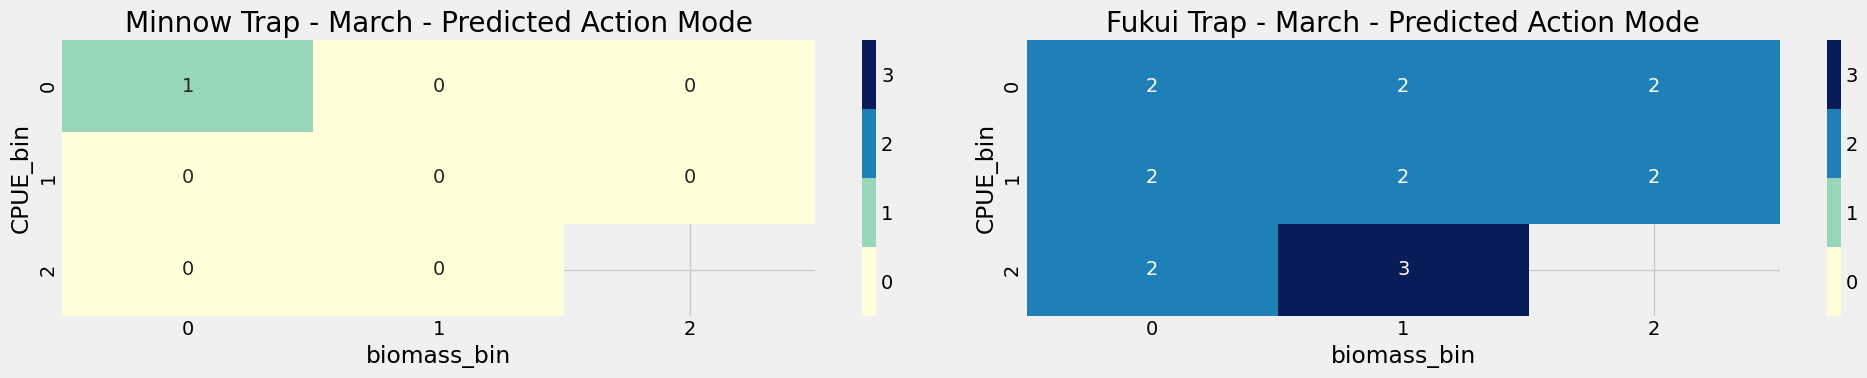

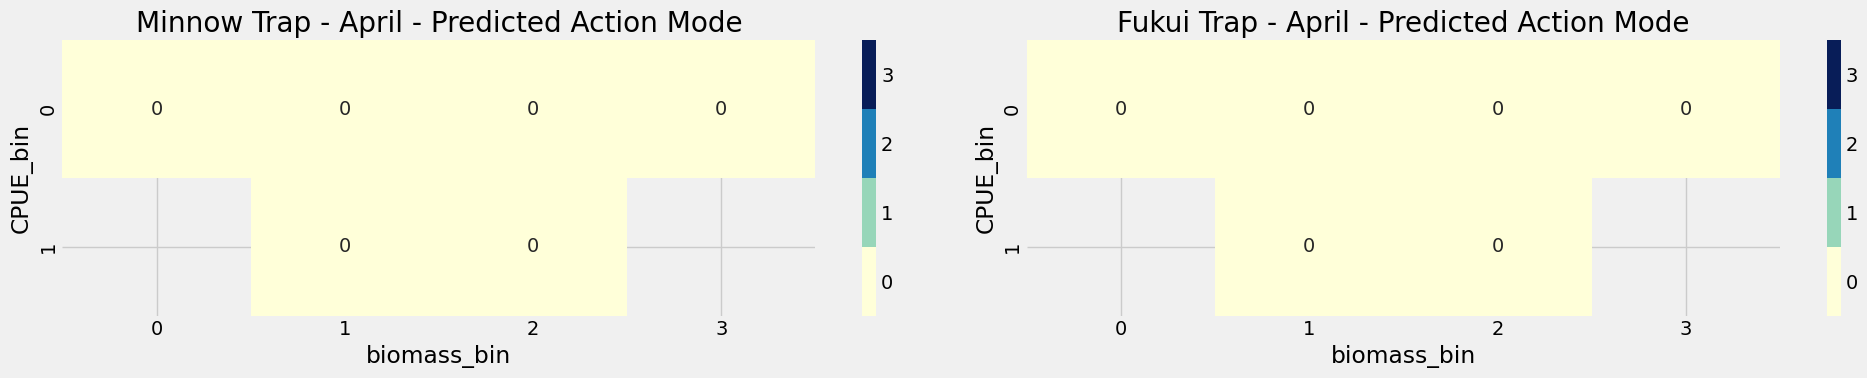

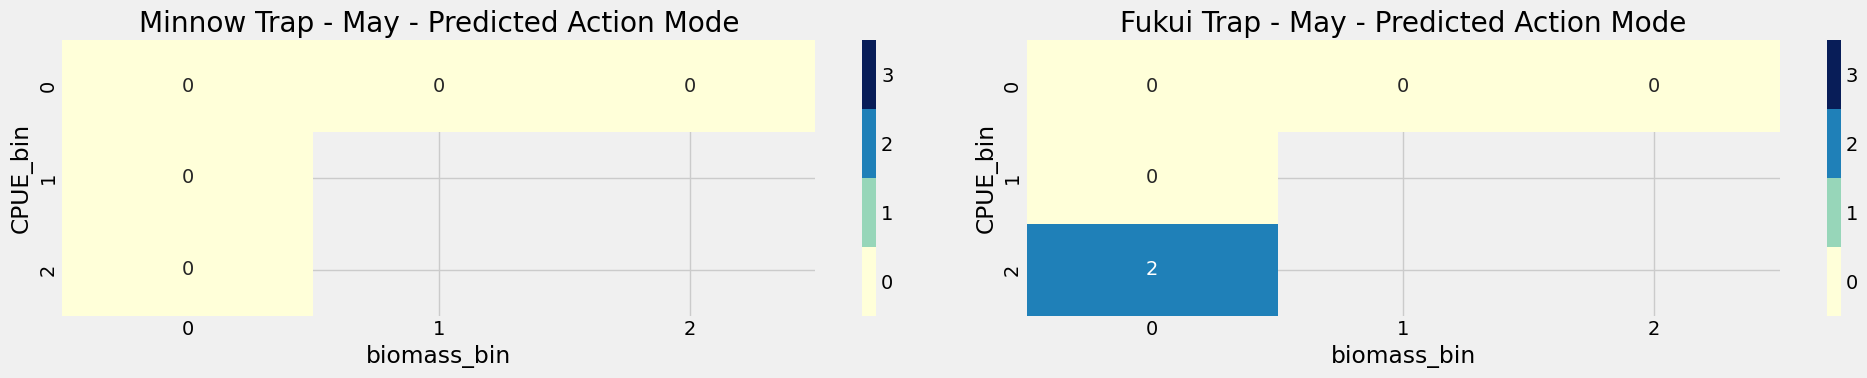

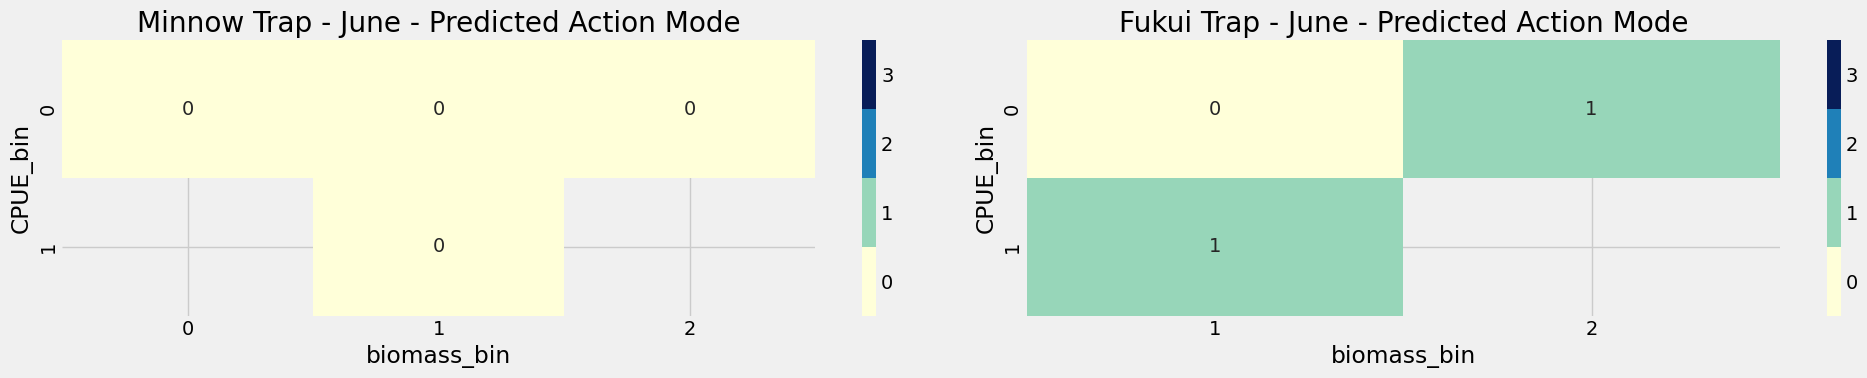

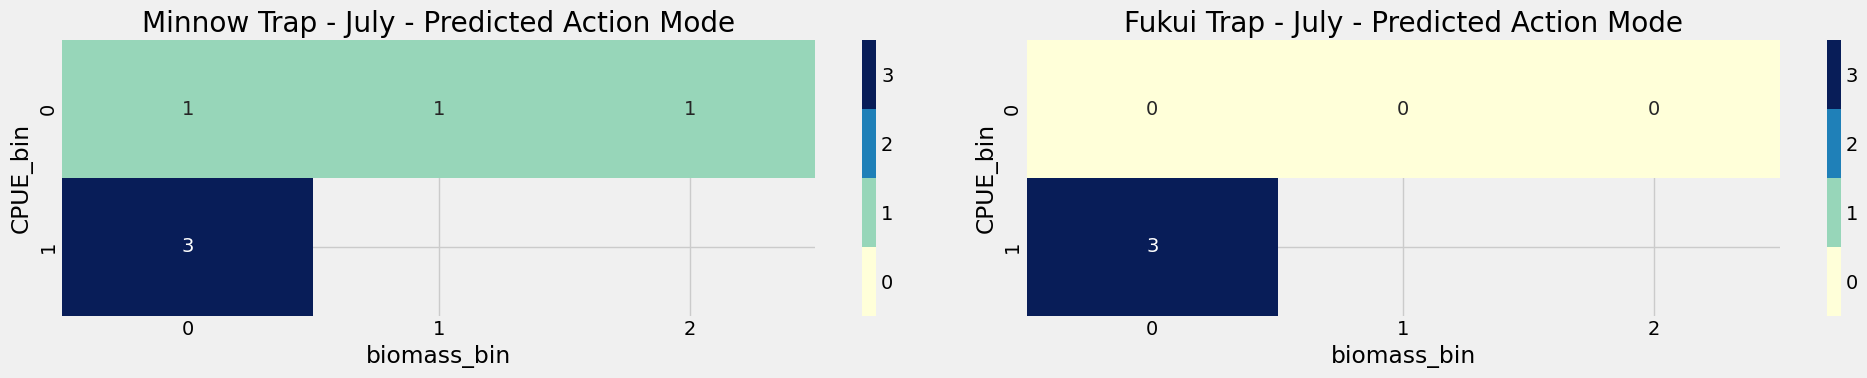

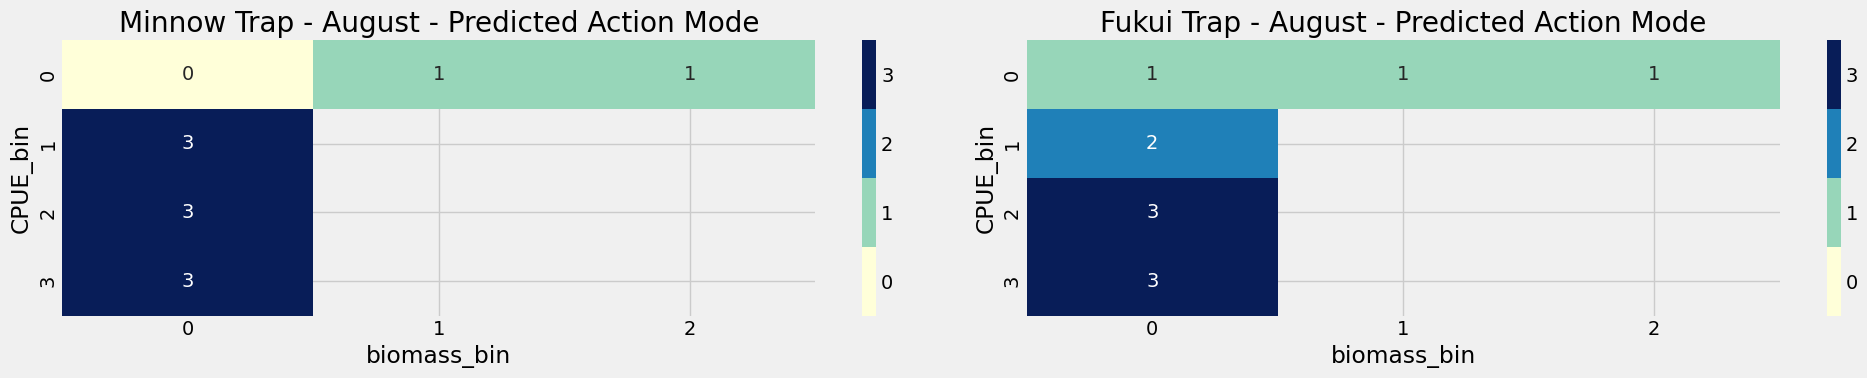

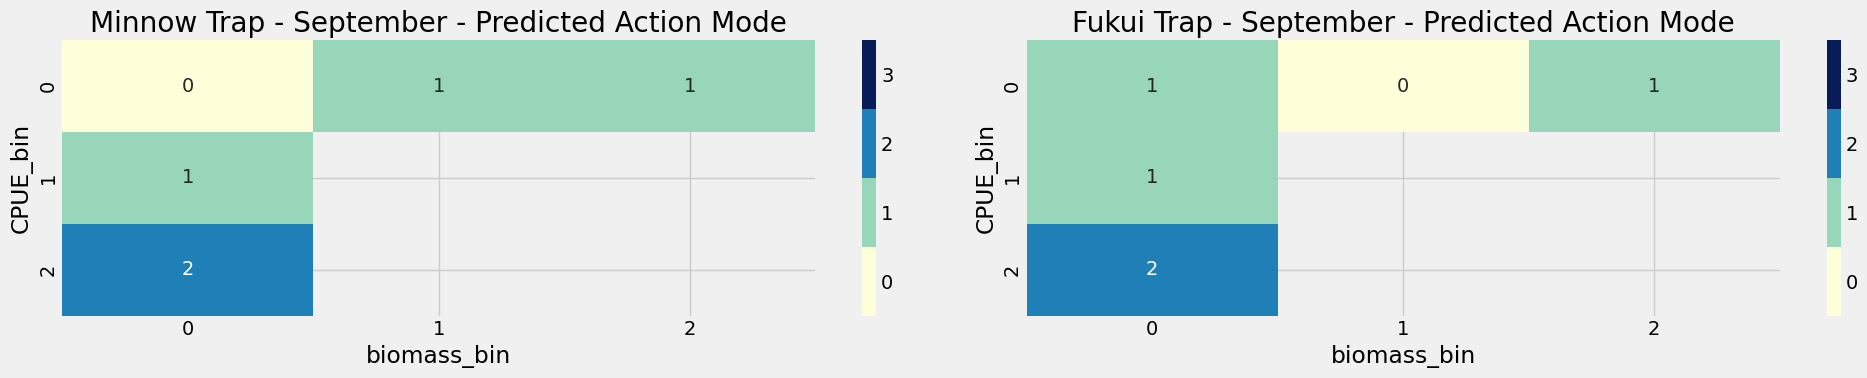

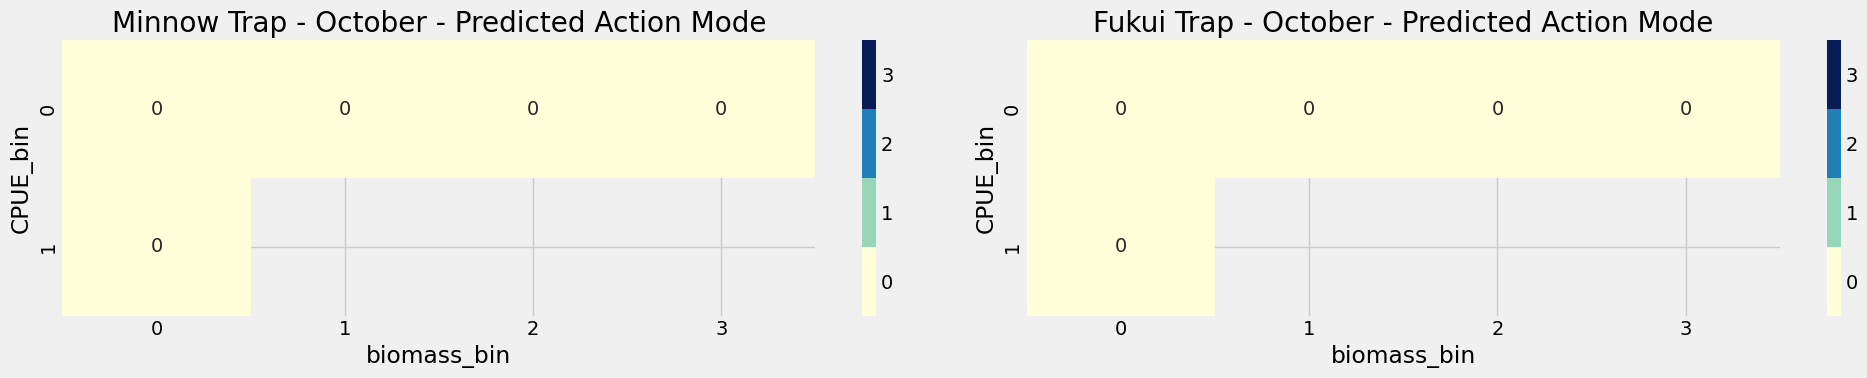

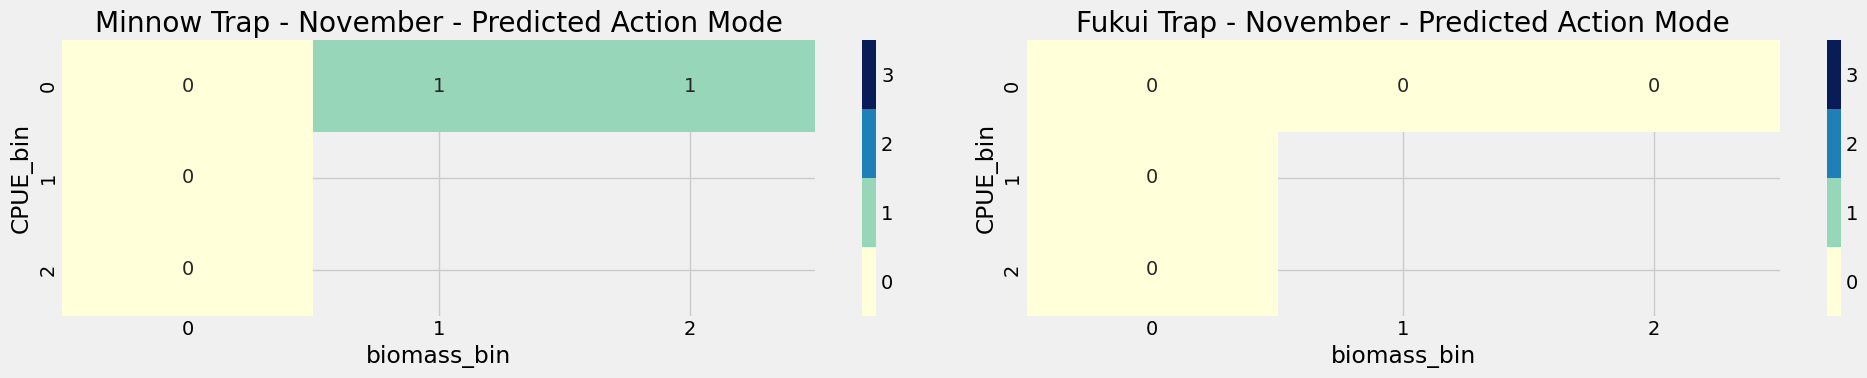

In [33]:
minnow_df = X0_test.copy()
minnow_df['actual'] = y0_test
minnow_df['lgb_pred'] = lgb_y0_pred

fukui_df = X1_test.copy()
fukui_df['actual'] = y1_test
fukui_df['lgb_pred'] = lgb_y1_pred

month_dict = {3: "March", 4: "April", 5: "May", 6: "June", 7: "July", 8:"August", 9: "September", 10: "October", 11: "November"}
trap_dfs = [minnow_df, fukui_df]
trap_dict = {0: "Minnow", 1: "Fukui"}

cmap = plt.get_cmap("YlGnBu", 4)

for month in month_dict.keys():
    fig, axes = plt.subplots(1, 2, figsize=(20, 4))
    for i in range(2):
        df = trap_dfs[i]
        curr_month = df[df["months"] == month]
    
        lgb_preds = pd.pivot_table(data = curr_month, index="CPUE_bin", columns="biomass_bin", values="lgb_pred", aggfunc=lambda x: x.mode().iloc[0])
    
        sns.heatmap(lgb_preds, annot=True, cmap=cmap, vmin=-0.5, vmax=3.5, ax=axes[i])
        axes[i].set_title(f"{trap_dict[i]} Trap - {month_dict[month]} - Predicted Action Mode")
    
    plt.tight_layout()
    plt.show()